# Snapshot eval catplot — PPO vs SAC vs DreamerV3 across the held-out battery-power × PV settings

Compares **per-episode eval metrics** across algorithms, drawing **one figure per (metric, eval
setting)** — a single run covers every setting the snapshots hold (`eval_0` … `eval_5`).

The x-axis carries the **algorithms** (PPO, SAC, DreamerV3) plus an **RBC group** of rule-based
baselines. Within a group's slot its **variants** are dodged side by side — the RL slots over
the three training variants declared in `SOURCES`, the RBC slot over the strategies in
`RBC_STRATEGIES`. Each slot dodges **only its own variants**, so the strategies do not shatter
the RL slots. One dot per eval episode, coloured by variant, with a **stat glyph** beside it
(mean, mean ± 1 std, median, min, max).

All nine snapshots (`snapshots/20260928_*_gen_lin_bat_power_pv_*`, trial YAMLs under
`configs/trial_cfgs/v0/GEN/gs_lin_bat_power_pv/`) share one environment — battery capacity
pinned at 10 kWh, a 5 kW wind turbine, household consumers (8 kW peak), a rule-based heat pump
and EV charger (`HPRbc`, `EvcsRbc`: consumers without a policy action), the
`EconomicSellFactorRewardV0` reward (`sell_price_factor: 0.7`) and 28 000 training episodes as
the budget — and differ only in the battery max power and PV rating seen while training:

| Variant | Training battery max power × PV rating |
|---|---|
| spec | single mid-grid config `cfg_5`: battery 9 kW, PV 10 kW |
| N-way gen. | infra schedule cycling the 3 × 3 grid `cfg_1…9` — battery 3 / 9 / 15 kW × PV 5 / 10 / 15 kW — every 4 episodes (`swap_every_n_episodes: 4`) |
| gen. distribution | `BatteryLinearWrapper` + `SolarPanelWrapper` drawing battery 3-15 kW × PV 5-15 kW at every reset (uniform, rounded to 0.1 kW), redrawn while on a held-out value (3.7 / 8.0 / 11.0 kW, 6 / 12 kW); infra schedule `mode: "off"` |

The six held-out eval settings (`configs/infra_cfgs/GEN/battery_lin_power_pv/cfg_eval_<i>.yaml`,
identical in all nine snapshots) combine both axes — interpolation points inside both training
ranges. The Ray eval writes one result directory per setting, `cfg_eval_<i>/`:

| Setting | Infra YAML | Battery max power | PV rating |
|---|---|---|---|
| `eval_0` | `cfg_eval_0.yaml` | 3.7 kW | 6 kW |
| `eval_1` | `cfg_eval_1.yaml` | 3.7 kW | 12 kW |
| `eval_2` | `cfg_eval_2.yaml` | 8.0 kW | 6 kW |
| `eval_3` | `cfg_eval_3.yaml` | 8.0 kW | 12 kW |
| `eval_4` | `cfg_eval_4.yaml` | 11.0 kW | 6 kW |
| `eval_5` | `cfg_eval_5.yaml` | 11.0 kW | 12 kW |

PDFs are written at **final print size** so `FIGURES_PER_A4_PAGE` (3) of them plus captions fill
one A4 text block — see "Catplots with stat glyphs" below. With six settings, one metric's six
PDFs fill **two** pages: e.g. `eval_0…2` and `eval_3…5`, or one page per PV rating
(`eval_0`/`2`/`4` = 6 kW, `eval_1`/`3`/`5` = 12 kW).

All eval runs of a source's eval kind are pooled (default run plus `_seed<N>` fan-outs).
Duplicate (setting, seed) CSVs within a source are dropped with a note, since the same
checkpoint on the same seed and setting replays identical episodes. A source whose snapshot has
no eval results yet is skipped with a warning, so the comparison stays runnable while evals are
pending. No rule-based eval (`runs/eval_rbc_*`) existed for any of the nine snapshots when this
notebook was set up (2026-09-30), so the RBC group only appears once one has run on
`RBC_SNAPSHOT`. The three DreamerV3 trainings stopped before their 28 000-episode budget (see
`sps_train_return_convergence.ipynb`).

`SEEDS` narrows every source to one seed (`42`), a list (`[42, 43]`, pooled) or all (`None`);
it is set to `[42]` here. The seed matched against is the one each run recorded in its **own
metadata** — sidecar JSON `"seed"` for `eval-ray`/`eval-sb`, `args.json` `"resolved_seed"` for
`eval-rbc` — never the directory name, so the un-suffixed default run matches on its real
`trial.seed`. Sources with no run on a wanted seed are skipped with a warning.

Two result layouts are discovered at once and kept apart as separate **settings**
(`EVAL_CFGS` picks which are drawn):

| Layout | Result CSVs | Setting label |
|---|---|---|
| STA (single eval config) | `eval_results/*_eval/eval_*.csv` | `default` |
| GEN (held-out configs) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` | `eval_<i>` |

Eval kinds mirror `sps_eval_violins_evalcfg_cmp.ipynb`:

| `eval-kind` | Run directory pattern | Producer | Per-run CSV |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `episodes.csv` |

**Main input:** `SOURCES`, `RBC_STRATEGIES`, `VARIANT_COLORS`, `EVAL_CFGS`, `EVAL_CFG_LABELS`
and `SEEDS` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# One source per (algorithm, training variant). Algorithms are drawn left to right on
# the x-axis (first-appearance order); the variants are dodged side by side within
# each algorithm's slot (first-appearance order, coloured via VARIANT_COLORS).
# Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* dirs to use
#   algo          x-axis category (also used in the PDF filenames)
#   variant       training-variant label, the dodge/hue group (shared across algos)
#   runs          (optional) restrict to these runs/<name> directories; default: all
#   rbc-strategy  (eval-rbc only) which rule-based strategy to use

# snapshots/20260928_001132_gen_lin_bat_power_pv_all_ppo
# snapshots/20260928_001142_gen_lin_bat_power_pv_sampled_ppo
# snapshots/20260928_001151_gen_lin_bat_power_pv_spec_ppo
# snapshots/20260928_001235_gen_lin_bat_power_pv_all_sac
# snapshots/20260928_001243_gen_lin_bat_power_pv_sampled_sac
# snapshots/20260928_001255_gen_lin_bat_power_pv_spec_sac
# snapshots/20260928_001328_gen_lin_bat_power_pv_sampled_dreamerv3
# snapshots/20260928_001354_gen_lin_bat_power_pv_spec_dreamerv3
# snapshots/20260928_001505_gen_lin_bat_power_pv_all_dreamerv3

SOURCES = [
    # --- PPO -------------------------------------------------------------------
    {
        "path": "snapshots/20260928_001151_gen_lin_bat_power_pv_spec_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "spec",
    },
    {
        "path": "snapshots/20260928_001132_gen_lin_bat_power_pv_all_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "N-way gen.",
    },
    {
        "path": "snapshots/20260928_001142_gen_lin_bat_power_pv_sampled_ppo",
        "eval-kind": "eval-ray",
        "algo": "PPO",
        "variant": "gen. distribution",
    },
    # --- SAC -------------------------------------------------------------------
    {
        "path": "snapshots/20260928_001255_gen_lin_bat_power_pv_spec_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "spec",
    },
    {
        "path": "snapshots/20260928_001235_gen_lin_bat_power_pv_all_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "N-way gen.",
    },
    {
        "path": "snapshots/20260928_001243_gen_lin_bat_power_pv_sampled_sac",
        "eval-kind": "eval-ray",
        "algo": "SAC",
        "variant": "gen. distribution",
    },
    # --- DreamerV3 (all three trainings stopped before 28 000 episodes) ----------
    {
        "path": "snapshots/20260928_001354_gen_lin_bat_power_pv_spec_dreamerv3",
        "eval-kind": "eval-ray",
        "algo": "DreamerV3",
        "variant": "spec",
    },
    {
        "path": "snapshots/20260928_001505_gen_lin_bat_power_pv_all_dreamerv3",
        "eval-kind": "eval-ray",
        "algo": "DreamerV3",
        "variant": "N-way gen.",
    },
    {
        "path": "snapshots/20260928_001328_gen_lin_bat_power_pv_sampled_dreamerv3",
        "eval-kind": "eval-ray",
        "algo": "DreamerV3",
        "variant": "gen. distribution",
    },
]

# Rule-based baselines: every strategy of this snapshot's eval_rbc run becomes one
# strip in the "RBC" x-axis group (drop entries here to trim the group). The
# rule-based eval is policy-independent — any of the nine snapshots works, they share
# the eval infra configs, reward and eval data schedule. No eval_rbc run exists for
# them yet (2026-09-30): until `--kind eval-rbc` has run on RBC_SNAPSHOT, every RBC
# source is skipped with a warning and the RBC group stays empty.
RBC_SNAPSHOT = "snapshots/20260928_001132_gen_lin_bat_power_pv_all_ppo"

RBC_STRATEGIES = (
    "do_nothing",
    "deficit_discharge",
    # "pv_surplus_charge",
    "self_coverage",
    "price_median",
    "price_median_scaled_0.25",
    # "price_median_scaled_0.5",
    # "price_median_scaled_0.75",
    "price_median_autarky",
)
SOURCES += [
    {"path": RBC_SNAPSHOT, "eval-kind": "eval-rbc", "algo": "RBC",
     "variant": strategy, "rbc-strategy": strategy}
    for strategy in RBC_STRATEGIES
]

# Episode-dot colour per variant, identical across the algorithm groups.
VARIANT_COLORS = {
    # RL training variants (same hues as the battery-capacity x PV catplot, 6_gen_bat_cap_pv_power)
    "spec": "#3f83d4",
    "N-way gen.": "#a855d8",
    "gen. distribution": "#2f9e6e",
    # RBC strategies (own x-group; the price_median family shares a teal ramp)
    "do_nothing": "#5c6670",
    "deficit_discharge": "#c05746",
    # "pv_surplus_charge": "#bfa229",
    "self_coverage": "#4a5899",
    "price_median": "#0f6a60",
    "price_median_scaled_0.25": "#8ec7c0",
    "price_median_scaled_0.5": "#55a79d",
    "price_median_scaled_0.75": "#2c887d",
    "price_median_autarky": "#c26fa1",
}

# The eval settings to draw — one figure per (metric, setting), all produced by a
# single run of this notebook. None = every setting discovered: the held-out `eval_<i>`
# configs of the GEN layout (numerically sorted), and "default" for a flat STA layout
# (CSVs directly under eval_results/*_eval/). Or an explicit tuple to restrict them,
# e.g. ("eval_0", "eval_2", "eval_4") for one A4 page of the PV 6 kW settings.
EVAL_CFGS: tuple[str, ...] | None = None

# Optional display names for the settings, keyed by the discovered `eval_<i>` label.
# Only used in the console log and the figure captions you write around the PDFs —
# the data keys and the PDF filenames keep the raw `eval_<i>`. Unlisted settings keep
# their raw label. Here: the held-out (battery max power, PV rating) pairs of the
# snapshots' own configs/infra_cfgs/GEN/battery_lin_power_pv/cfg_eval_<i>.yaml
# (battery capacity pinned at 10 kWh in all of them).
EVAL_CFG_LABELS: dict[str, str] = {
    "eval_0": "BES 3.7 kW, PV 6 kW",
    "eval_1": "BES 3.7 kW, PV 12 kW",
    "eval_2": "BES 8.0 kW, PV 6 kW",
    "eval_3": "BES 8.0 kW, PV 12 kW",
    "eval_4": "BES 11.0 kW, PV 6 kW",
    "eval_5": "BES 11.0 kW, PV 12 kW",
}

# Eval seeds to keep, applied to every source after discovery:
#   SEEDS = None       keep every discovered seed (default)
#   SEEDS = 42         keep only the eval run seeded 42
#   SEEDS = [42, 43]   keep those two seeds, pooled into each strip
# Matched against the seed every run recorded itself (sidecar JSON "seed" for
# eval-ray/eval-sb, args.json "resolved_seed" for eval-rbc), never the directory name.
# A source with no run on any wanted seed is skipped with a warning, so narrowing to the
# `_seed<N>` fan-out seeds drops sources that only ever ran the default seed.
SEEDS: int | list[int] | None = [42]

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_power_eval_1);
# training-config directories (e.g. battery_lin_power_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# `eval_<i>` for a held-out eval-config result dir name, None for anything else.
def _cfg_dir_setting(dir_name: str) -> str | None:
    match = _EVAL_CFG_DIR_PATTERN.search(dir_name)
    return f"eval_{match.group(1)}" if match else None


# Ray/SB3 eval CSVs carry a sidecar JSON (same stem) with the run's trial seed + algorithm.
def _sidecar_seed_and_algorithm(csv_path: Path) -> tuple[int | None, str | None]:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None, None
    try:
        payload = json.loads(sidecar.read_text())
    except (json.JSONDecodeError, OSError):
        return None, None
    return payload.get("seed"), payload.get("algorithm")


# Rule-based runs record resolved_seed in an args.json above episodes.csv (directly
# above the per-strategy dir in the flat layout, one level further up with per-config
# dirs) — walk up towards the run dir and take the first hit.
def _rbc_resolved_seed(csv_path: Path, run_dir: Path) -> int | None:
    for candidate_dir in csv_path.parents:
        args_path = candidate_dir / "args.json"
        if args_path.is_file():
            try:
                return json.loads(args_path.read_text()).get("resolved_seed")
            except (json.JSONDecodeError, OSError):
                return None
        if candidate_dir == run_dir:
            return None
    return None


# Discovers one record per eval CSV of `source` across ALL eval settings kept by
# EVAL_CFGS (None = no filter). Both layouts are globbed; every record is tagged with
# its setting ("default" for the flat STA layout, `eval_<i>` for held-out GEN config
# dirs), which is what the per-setting figures are drawn from.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if wanted_runs := source.get("runs"):
        run_dirs = [run_dir for run_dir in run_dirs if run_dir.name in set(wanted_runs)]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            # flat: .../<strategy>/episodes.csv — nested: .../<strategy>/<cfg>_eval_<i>/episodes.csv
            candidates = [
                (csv_path, "default", csv_path.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name), csv_path.parent.parent.name)
                for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            ]
            strategies = sorted({strategy for _, _, strategy in candidates})
            strategy_wanted = source.get("rbc-strategy")
            if strategy_wanted is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['algo']} — {source['variant']}': multiple rule-based strategies "
                    f"{strategies} under {run_dir.name} — set 'rbc-strategy' to pick one."
                )
            for csv_path, setting, strategy in candidates:
                if setting is None or (strategy_wanted is not None and strategy != strategy_wanted):
                    continue
                records.append({
                    "algo": source["algo"], "variant": source["variant"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "setting": setting, "seed": _rbc_resolved_seed(csv_path, run_dir),
                    "eval_algorithm": strategy, "csv": csv_path,
                })
        else:
            candidates = [
                (csv_path, "default")
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv"))
            ] + [
                (csv_path, _cfg_dir_setting(csv_path.parent.name))
                for csv_path in sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
            ]
            for csv_path, setting in candidates:
                if setting is None:
                    continue  # training-config result dir — not a held-out eval config
                seed, algorithm = _sidecar_seed_and_algorithm(csv_path)
                records.append({
                    "algo": source["algo"], "variant": source["variant"], "snapshot_dir": snapshot_dir,
                    "run": run_dir.name, "setting": setting, "seed": seed,
                    "eval_algorithm": algorithm, "csv": csv_path,
                })

    available = sorted({record["setting"] for record in records})
    if EVAL_CFGS is not None:
        records = [record for record in records if record["setting"] in set(EVAL_CFGS)]
    if not records:
        raise FileNotFoundError(
            f"Source '{source['algo']} — {source['variant']}': no eval CSVs on setting(s) "
            f"{'all discovered' if EVAL_CFGS is None else EVAL_CFGS} under {snapshot_dir} "
            f"(available: {available or 'none'}) — adjust EVAL_CFGS or the source."
        )
    return records


_source_keys = [(source["algo"], source["variant"]) for source in SOURCES]
if len(_source_keys) != len(set(_source_keys)):
    raise ValueError(f"Every source needs a unique (algo, variant) pair; got {_source_keys}")
_missing_colors = sorted({source["variant"] for source in SOURCES} - set(VARIANT_COLORS))
if _missing_colors:
    raise ValueError(f"VARIANT_COLORS lacks an entry for variant(s) {_missing_colors}")

# SEEDS normalised to the set of wanted seeds (None = keep every discovered seed): a
# bare int selects one seed, any iterable of ints selects several.
SEED_FILTER: set[int] | None = (
    None if SEEDS is None else {int(seed) for seed in ([SEEDS] if isinstance(SEEDS, int) else SEEDS)}
)
if SEED_FILTER is not None and not SEED_FILTER:
    raise ValueError("SEEDS is empty — use None to keep every discovered seed, or name the seed(s) to keep.")

# Pool a source's eval runs — narrowed to SEED_FILTER when set — but keep only the first
# CSV per (setting, seed): the same checkpoint evaluated with the same seed on the same
# setting replays the identical eval episodes, so a duplicate would double-count them.
# Seed-less CSVs are kept and flagged while no seed filter is active (with one they
# cannot match, so they are dropped). A source left with nothing — eval run still
# pending, or no run on any wanted seed — is skipped with a warning.
eval_records: list[dict] = []
print(f"Repo root    : {REPO_ROOT}")
print(f"Eval settings: {'all discovered' if EVAL_CFGS is None else EVAL_CFGS}")
print(f"Eval seeds   : {sorted(SEED_FILTER) if SEED_FILTER is not None else 'all discovered (SEEDS = None)'}")
for source in SOURCES:
    try:
        discovered = sorted(_discover_source_records(source),
                            key=lambda record: (record["setting"], record["run"], record["csv"].name))
    except FileNotFoundError as error:
        print(f"\nWARNING: source '{source['algo']} — {source['variant']}' skipped — {error}")
        continue

    if SEED_FILTER is not None:
        for record in discovered:
            if record["seed"] is None:
                print(f"note: source '{source['algo']} — {source['variant']}': dropped {record['run']} / "
                      f"{record['csv'].name} on {record['setting']} (no seed resolvable — cannot match SEEDS)")
        seeds_available = sorted({record["seed"] for record in discovered if record["seed"] is not None})
        discovered = [record for record in discovered if record["seed"] in SEED_FILTER]
        if not discovered:
            print(f"\nWARNING: source '{source['algo']} — {source['variant']}' skipped — no eval CSVs with a "
                  f"seed in {sorted(SEED_FILTER)} (seeds available: {seeds_available or 'none'}) — "
                  "adjust SEEDS or the source.")
            continue

    kept, seen = [], set()
    for record in discovered:
        if record["seed"] is not None and (record["setting"], record["seed"]) in seen:
            print(f"note: source '{source['algo']} — {source['variant']}': dropped {record['run']} / "
                  f"{record['csv'].name} on {record['setting']} (duplicate seed {record['seed']})")
            continue
        if record["seed"] is None:
            print(f"WARNING: source '{source['algo']} — {source['variant']}': no seed resolvable for "
                  f"{record['csv'].name} on {record['setting']} — kept, duplicate eval runs undetectable")
        else:
            seen.add((record["setting"], record["seed"]))
        kept.append(record)
    eval_records.extend(kept)

    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['algo']} — {source['variant']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in kept:
        print(f"  {record['setting']:>8}  seed {str(record['seed']):>5}  <-  {record['run']} / "
              f"{record['csv'].name}  [{record['eval_algorithm']}]")

if not eval_records:
    raise FileNotFoundError("No eval CSVs discovered for any source — nothing to plot.")

# x-axis / hue orders = first-appearance order in SOURCES, restricted to the sources
# that yielded eval results. Which of them actually appear in one figure is narrowed
# again per eval setting (a source may lack results for a single setting).
_algos_with_records = {record["algo"] for record in eval_records}
_variants_with_records = {record["variant"] for record in eval_records}
algo_labels = list(dict.fromkeys(source["algo"] for source in SOURCES if source["algo"] in _algos_with_records))
variant_labels = list(dict.fromkeys(source["variant"] for source in SOURCES if source["variant"] in _variants_with_records))
variant_palette = {variant: VARIANT_COLORS[variant] for variant in variant_labels}


# Figure order: the flat "default" setting first (if present), then eval_<i> numerically.
def _setting_sort_key(setting: str) -> tuple[int, int]:
    match = re.fullmatch(r"eval_(\d+)", setting)
    return (0, 0) if match is None else (1, int(match.group(1)))


setting_labels = sorted({record["setting"] for record in eval_records}, key=_setting_sort_key)

# Warn where a source does not cover every drawn setting: its strip is simply absent from
# those figures (e.g. an RBC snapshot whose rule-based run holds fewer held-out configs
# than the RL snapshots do).
for source in SOURCES:
    covered = {record["setting"] for record in eval_records
               if record["algo"] == source["algo"] and record["variant"] == source["variant"]}
    uncovered = [setting for setting in setting_labels if setting not in covered]
    if covered and uncovered:
        print(f"WARNING: source '{source['algo']} — {source['variant']}' has no eval results on "
              f"{uncovered} — it is absent from those figures.")

print(f"\nEval settings to draw (one figure per metric each): "
      f"{[f'{setting} ({EVAL_CFG_LABELS[setting]})' if setting in EVAL_CFG_LABELS else setting for setting in setting_labels]}")


Repo root    : /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Eval settings: all discovered
Eval seeds   : [42]

Source 'PPO — spec' (eval-ray): snapshots/20260928_001151_gen_lin_bat_power_pv_spec_ppo
    eval_0  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230539.csv  [ppo]
    eval_1  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230609.csv  [ppo]
    eval_2  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230636.csv  [ppo]
    eval_3  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230703.csv  [ppo]
    eval_4  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230729.csv  [ppo]
    eval_5  seed    42  <-  eval_20260930_230239 / eval_checkpoint_000233_20260930_230756.csv  [ppo]

Source 'PPO — N-way gen.' (eval-ray): snapshots/20260928_001132_gen_lin_bat_power_pv_all_ppo
    eval_0  seed    42  <-  eval_20260930_230237 / eval_checkpoint_000233_20260930_230539.csv  [ppo]


## Output naming

Everything saved here lands next to the notebook as
`[<tag>_]<date>_<time>_out_<i>.<file format>`: one timestamp per notebook run, `out_index`
counting up per saved artefact. The figures pass their eval setting as `tag`, so one run's PDFs
read `eval_1_<date>_<time>_out_1.pdf`, `eval_2_…_out_2.pdf`, … — the setting is part of the
filename rather than something to remember per run.

In [3]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str, tag: str | None = None) -> Path:
    """Next '[<tag>_]<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    prefix = f"{tag}_" if tag else ""
    return OUT_DIR / f"{prefix}{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


## Load per-episode metrics

The kept CSVs are concatenated into one frame with a row per eval episode and the metrics as
columns, each row tagged with its `algo`, training `variant`, `eval_cfg` (the setting the
figures split on) and eval `seed`. A CSV missing a metric column is simply absent from that
metric's figures. The table below has one row per strip drawn later.

In [4]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['algo']} — {record['variant']}' {record['run']} "
              f"({record['setting']}) lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["algo"] = record["algo"]
    frame["variant"] = record["variant"]
    frame["eval_cfg"] = record["setting"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

# One row per strip drawn below: (eval setting, algorithm, variant).
episodes.groupby(["eval_cfg", "algo", "variant"]).agg(
    episodes=("seed", "size"),
    eval_seeds=("seed", "nunique"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
).reindex(setting_labels, level="eval_cfg").reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")


episodes  eval_seeds  mean_total_reward  \
eval_cfg algo      variant                                                      
eval_0   PPO       spec                     10           1         -31.345105   
                   N-way gen.               10           1         -31.345105   
                   gen. distribution        10           1         -31.345105   
         SAC       spec                     10           1         -31.142226   
                   N-way gen.               10           1         -29.745437   
...                                        ...         ...                ...   
eval_5   SAC       N-way gen.               10           1         -23.937446   
                   gen. distribution        10           1         -24.928007   
         DreamerV3 spec                     10           1         -24.177726   
                   N-way gen.               10           1         -25.324158   
                   gen. distribution        10           1         -23.881986   

                                      mean_cum_E_kWh  mean_cum_price_EUR  
eval_cfg algo      variant                                                
eval_0   PPO       spec                   -38.721610            6.251721  
                   N-way gen.             -38.721610            6.251721  
                   gen. distribution      -38.721610            6.251721  
         SAC       spec                   -38.721610            6.216191  
                   N-way gen.             -38.733258            5.966488  
...                                              ...                 ...  
eval_5   SAC       N-way gen.               1.269247            4.670621  
                   gen. distribution        1.269247            4.857013  
         DreamerV3 spec                     0.652179            4.736681  
                   N-way gen.               1.269247            4.810296  
                   gen. distribution        1.066881            4.651618  

[76 rows x 5 columns]

## Catplots with stat glyphs

One categorical strip figure per **(metric, eval setting)** — the axes-level form of
`catplot(kind="strip")`, one `stripplot` layer per algorithm so each slot dodges over **its own
variants only**. Each strip shows one dot per eval episode in its `VARIANT_COLORS` colour, with
a **stat glyph** beside it:

- thin capped vertical line — **min … max** span,
- thick grey bar — **mean ± 1 std**,
- red dot — **mean**,
- black dashed line — **median**.

### Print geometry — 3 figures + captions on one A4 page

PDFs are saved at **final print size**: no `bbox_inches="tight"`, so the page is exactly
`FIGURE_WIDTH_IN × FIGURE_HEIGHT_IN`, and the legend uses constrained layout's `outside`
location, which reserves space **inside** that page instead of growing it:

```
FIGURE_WIDTH_IN  = A4_TEXT_WIDTH_IN                                            = 6.30 in  (160 mm)
FIGURE_HEIGHT_IN = (A4_TEXT_HEIGHT_IN - FIGURES_PER_A4_PAGE * CAPTION_ALLOWANCE_IN)
                   / FIGURES_PER_A4_PAGE                                       = 2.40 in  (61 mm)
```

Three of them plus `CAPTION_ALLOWANCE_IN` each fill one 160 × 240 mm text block. Include them at
natural size — with a 160 mm text block `\includegraphics[width=\textwidth]{...}` is equivalent,
so the point sizes set below are the point sizes on paper. Adjust the constants for a different
text block (`\the\textwidth` / `\the\textheight`, 1 in = 72.27 pt).

`SHARE_Y_ACROSS_EVAL_CFGS` puts all settings of one metric on a **common y-axis** so the stacked
figures compare directly — across both pages of the six settings too; `False` gives per-figure
autoscale.

The figures carry **no title** (thesis-ready) — name the setting in the LaTeX caption
(`EVAL_CFG_LABELS` holds the display names). Each is saved as
`<eval_cfg>_<date>_<time>_out_<i>.pdf` next to this notebook.

In [5]:
from matplotlib.lines import Line2D

# --- Print geometry: FIGURES_PER_A4_PAGE figures + captions on one A4 page -----------
# The PDFs are saved WITHOUT bbox_inches="tight", so the saved page is exactly
# (FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN); the legend uses constrained layout's "outside"
# location, which reserves its space inside that page rather than growing it.
A4_TEXT_WIDTH_IN = 6.30      # 160 mm text block (A4 210 mm wide, 25 mm margins)
A4_TEXT_HEIGHT_IN = 9.45     # 240 mm text block (A4 297 mm tall, ~28 mm margins)
FIGURES_PER_A4_PAGE = 3      # six held-out settings here -> two pages of three per metric
CAPTION_ALLOWANCE_IN = 0.75  # per figure: ~2 caption lines at 10 pt + float separation

FIGURE_WIDTH_IN = A4_TEXT_WIDTH_IN
FIGURE_HEIGHT_IN = (A4_TEXT_HEIGHT_IN - FIGURES_PER_A4_PAGE * CAPTION_ALLOWANCE_IN) / FIGURES_PER_A4_PAGE

# All settings of one metric share a y-axis, so the stacked figures are comparable.
SHARE_Y_ACROSS_EVAL_CFGS = True

# Point sizes for that print size — the PDF is included at natural size, so these are
# the sizes on paper. The legend sits in one column beside the axes: ~13 entries at
# LEGEND_FONT_SIZE_PT fit into FIGURE_HEIGHT_IN; raise LEGEND_NCOL if more are needed.
LEGEND_FONT_SIZE_PT = 6.5
LEGEND_NCOL = 1
DOT_SIZE = 3.0        # episode dots (stripplot `size`)
GLYPH_MEAN_SIZE = 11  # mean dot area (scatter `s`)
GLYPH_RANGE_LW = 0.7  # min-max span + caps
GLYPH_STD_LW = 2.2    # mean ± 1 std bar
GLYPH_MEDIAN_LW = 0.8

sns.set_theme(style="whitegrid", context="paper", rc={
    "font.size": 8.0, "axes.labelsize": 8.0, "xtick.labelsize": 8.0,
    "ytick.labelsize": 7.0, "legend.fontsize": LEGEND_FONT_SIZE_PT,
    "axes.linewidth": 0.6, "grid.linewidth": 0.5,
})

# Short axis labels: at FIGURE_HEIGHT_IN the y-label is nearly as tall as the axes, so
# the long forms of the other notebooks would overflow the fixed-size page. Spell the
# metric out in the LaTeX caption instead.
METRIC_LABELS = {
    "total_reward": "Episode return",
    "cum_E_kWh": "Net grid energy exchange [kWh]",
    "cum_price_EUR": "Cumulative energy cost [EUR]",
}

# Stat-glyph inks (the episode dots carry the per-variant colours from VARIANT_COLORS)
MEAN_COLOR = "#e34948"    # red dot, matching the violin notebooks
MEDIAN_COLOR = "#1a1a19"  # dashed line, matching the violin notebooks
RANGE_COLOR = "#1a1a19"   # thin min-max span with caps
STD_COLOR = "#8a8a86"     # thick mean ± 1 std bar
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn's per-category slot width, shared by a slot's dodged variants


# The strips one eval setting's figure draws: the algorithms present in `data` (x-axis
# order) and, per algorithm, ITS OWN variants — both narrowed from the global orders,
# so a source missing on this setting simply drops out of that figure.
def _plot_orders(data: pd.DataFrame) -> tuple[list[str], dict[str, list[str]]]:
    pairs = set(zip(data["algo"], data["variant"]))
    algo_order = [algo for algo in algo_labels if any(algo == present for present, _ in pairs)]
    return algo_order, {
        algo: [variant for variant in variant_labels if (algo, variant) in pairs]
        for algo in algo_order
    }


# Geometry of one (algorithm, variant) strip within its algorithm's slot: the strip
# centre from seaborn's even hue split over that algorithm's OWN variants (mirroring
# _dodge_offset in sps_eval_violins_evalcfg_cmp), the glyph centre shifted slightly
# right of the dots, and the cap / median half-widths — all scaled to the sub-slot
# width, which differs between the groups (the RL slots carry the training variants,
# the RBC slot every strategy of RBC_STRATEGIES).
def _glyph_geometry(variants_here: list[str], variant: str) -> tuple[float, float, float]:
    sub_width = DODGE_WIDTH / len(variants_here)
    strip_centre = DODGE_WIDTH * ((variants_here.index(variant) + 0.5) / len(variants_here) - 0.5)
    return strip_centre + 0.3 * sub_width, 0.2 * sub_width, 0.35 * sub_width


# Overlays one stat glyph per (algorithm, variant) strip: min-max span (thin, capped),
# mean ± 1 std (thick grey bar), median (dashed line) and mean (red dot).
def _draw_stat_glyphs(ax, data: pd.DataFrame, metric: str,
                      algo_order: list[str], variants_by_algo: dict[str, list[str]]) -> None:
    stats = data.groupby(["algo", "variant"])[metric].agg(["mean", "std", "median", "min", "max"])
    for (algo, variant), row in stats.iterrows():
        if algo not in algo_order or variant not in variants_by_algo[algo]:
            continue
        glyph_offset, cap_half, median_half = _glyph_geometry(variants_by_algo[algo], variant)
        x_position = algo_order.index(algo) + glyph_offset
        ax.vlines(x_position, row["min"], row["max"], color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, zorder=4)
        ax.hlines([row["min"], row["max"]], x_position - cap_half, x_position + cap_half,
                  color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, zorder=4)
        if pd.notna(row["std"]):  # std is NaN for a single-episode group
            ax.vlines(x_position, row["mean"] - row["std"], row["mean"] + row["std"],
                      color=STD_COLOR, linewidth=GLYPH_STD_LW, zorder=5)
        ax.hlines(row["median"], x_position - median_half, x_position + median_half,
                  color=MEDIAN_COLOR, linewidth=GLYPH_MEDIAN_LW, linestyle=MEDIAN_DASH, zorder=6)
        ax.scatter(x_position, row["mean"], color=MEAN_COLOR, s=GLYPH_MEAN_SIZE,
                   edgecolor="white", linewidth=0.4, zorder=7)


# Common y-limits for one metric across every eval setting, so the stacked figures can
# be read against each other. Spans what is actually drawn — the min-max caps AND the
# mean ± 1 std bars, which can reach past the episode range for small samples — plus 5 %.
def _shared_ylim(metric: str) -> tuple[float, float] | None:
    data = episodes.dropna(subset=[metric])
    if data.empty:
        return None
    stats = data.groupby(["eval_cfg", "algo", "variant"])[metric].agg(["mean", "std", "min", "max"])
    spread = stats["std"].fillna(0.0)
    low = float(pd.concat([stats["min"], stats["mean"] - spread]).min())
    high = float(pd.concat([stats["max"], stats["mean"] + spread]).max())
    padding = 0.05 * (high - low) if high > low else 1.0
    return low - padding, high + padding


# Draws one categorical strip figure for `metric` on eval setting `eval_cfg`: per
# algorithm one dodged episode strip per variant, each beside its stat glyph (no figure
# title), and exports it as a PDF at final print size next to this notebook. One
# stripplot layer per algorithm, so each slot dodges over that algorithm's OWN variants
# — a single seaborn call would split every slot by the union of all variants.
def catplot_for_metric(metric: str, eval_cfg: str, ylim: tuple[float, float] | None = None) -> None:
    data = (episodes[episodes["eval_cfg"] == eval_cfg].dropna(subset=[metric])
            if metric in episodes.columns else episodes.iloc[0:0])
    if data.empty:
        print(f"no data for '{metric}' on {eval_cfg} — figure skipped")
        return
    algo_order, variants_by_algo = _plot_orders(data)

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN), layout="constrained")
    for algo in algo_order:
        sns.stripplot(
            data=data[data["algo"] == algo], x="algo", y=metric, hue="variant",
            order=algo_order, hue_order=variants_by_algo[algo], palette=variant_palette,
            dodge=len(variants_by_algo[algo]) > 1, jitter=True, size=DOT_SIZE, alpha=0.6,
            linewidth=0.2, edgecolor="white", legend=False, ax=ax,
        )
    _draw_stat_glyphs(ax, data, metric, algo_order, variants_by_algo)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="x", visible=False)

    variants_drawn = [variant for variant in variant_labels
                      if any(variant in variants for variants in variants_by_algo.values())]
    variant_handles = [
        Line2D([], [], color=variant_palette[variant], marker="o", linestyle="none",
               markersize=4, label=variant)
        for variant in variants_drawn
    ]
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=3.5,
               markeredgecolor="white", markeredgewidth=0.4, label="mean"),
        Line2D([], [], color=STD_COLOR, linewidth=3.0, solid_capstyle="butt", label="mean ± 1 std"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=GLYPH_MEDIAN_LW, linestyle=MEDIAN_DASH, label="median"),
        Line2D([], [], color=RANGE_COLOR, linewidth=GLYPH_RANGE_LW, marker="|", markersize=5, label="min / max"),
    ]
    # Figure-level legend with an "outside" loc: constrained layout reserves its width
    # INSIDE the figure, so the saved page keeps the exact A4-derived size above.
    fig.legend(handles=variant_handles + stat_handles, loc="outside right upper", title="",
               frameon=False, ncol=LEGEND_NCOL, labelspacing=0.35, handletextpad=0.5,
               borderaxespad=0.0)
    sns.despine(ax=ax)

    pdf_path = next_out_path("pdf", tag=eval_cfg)
    fig.savefig(pdf_path)  # no bbox_inches → the page is exactly FIGURE_WIDTH_IN x FIGURE_HEIGHT_IN
    setting_label = EVAL_CFG_LABELS.get(eval_cfg, eval_cfg)
    print(f"saved {pdf_path.name}  ({metric}, {eval_cfg} = {setting_label}, "
          f"{FIGURE_WIDTH_IN:.2f} x {FIGURE_HEIGHT_IN:.2f} in)")
    plt.show()

saved eval_0_20261001_102836_out_1.pdf  (total_reward, eval_0 = BES 3.7 kW, PV 6 kW, 6.30 x 2.40 in)


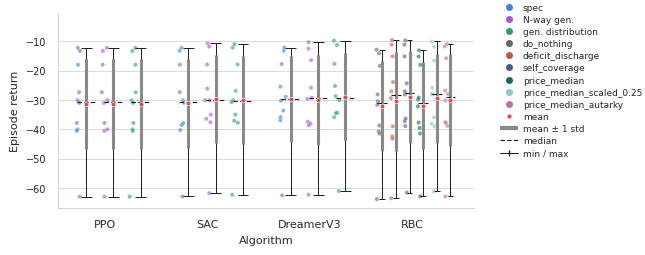

saved eval_1_20261001_102836_out_2.pdf  (total_reward, eval_1 = BES 3.7 kW, PV 12 kW, 6.30 x 2.40 in)


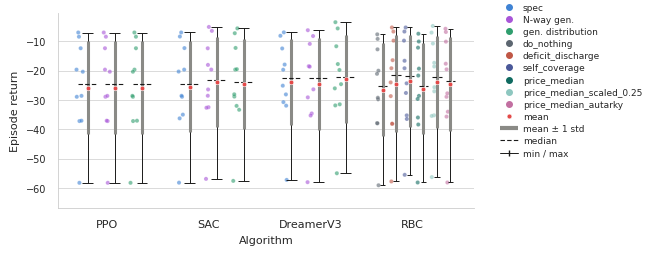

saved eval_2_20261001_102836_out_3.pdf  (total_reward, eval_2 = BES 8.0 kW, PV 6 kW, 6.30 x 2.40 in)


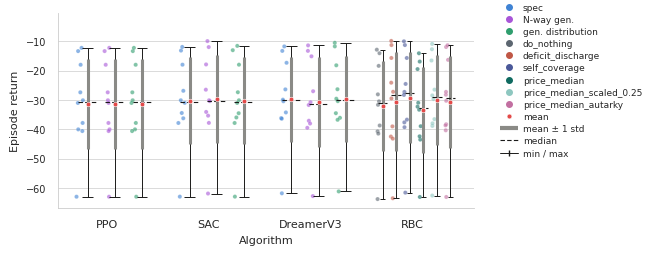

saved eval_3_20261001_102836_out_4.pdf  (total_reward, eval_3 = BES 8.0 kW, PV 12 kW, 6.30 x 2.40 in)


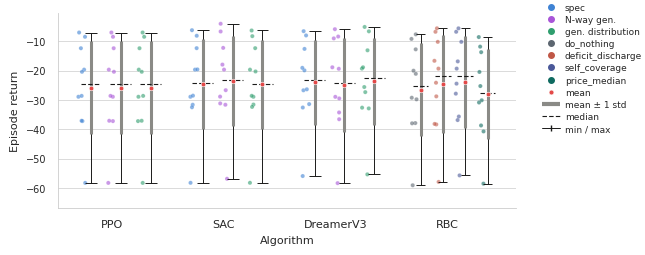

saved eval_4_20261001_102836_out_5.pdf  (total_reward, eval_4 = BES 11.0 kW, PV 6 kW, 6.30 x 2.40 in)


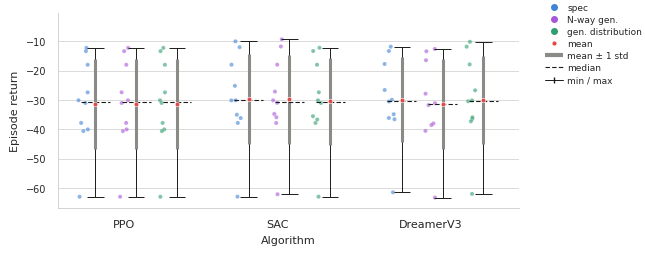

saved eval_5_20261001_102836_out_6.pdf  (total_reward, eval_5 = BES 11.0 kW, PV 12 kW, 6.30 x 2.40 in)


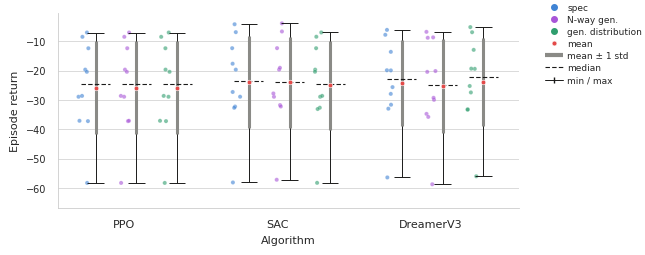

saved eval_0_20261001_102836_out_7.pdf  (cum_E_kWh, eval_0 = BES 3.7 kW, PV 6 kW, 6.30 x 2.40 in)


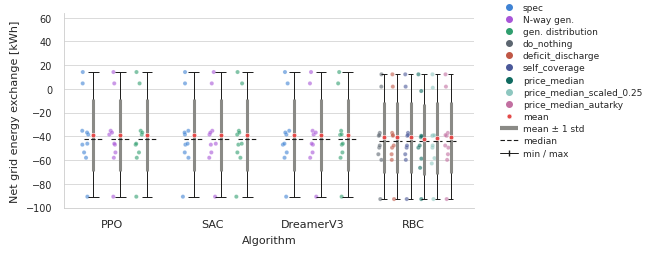

saved eval_1_20261001_102836_out_8.pdf  (cum_E_kWh, eval_1 = BES 3.7 kW, PV 12 kW, 6.30 x 2.40 in)


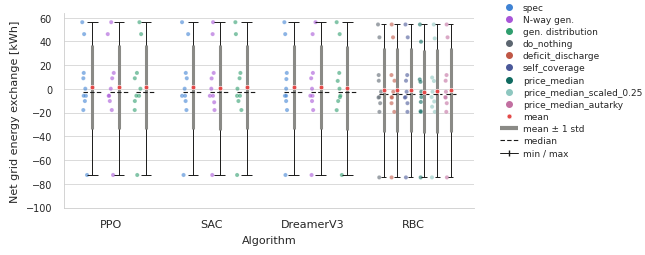

saved eval_2_20261001_102836_out_9.pdf  (cum_E_kWh, eval_2 = BES 8.0 kW, PV 6 kW, 6.30 x 2.40 in)


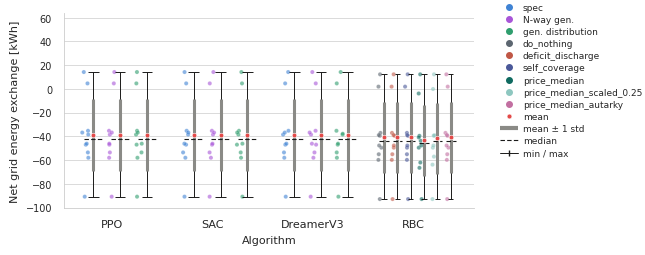

saved eval_3_20261001_102836_out_10.pdf  (cum_E_kWh, eval_3 = BES 8.0 kW, PV 12 kW, 6.30 x 2.40 in)


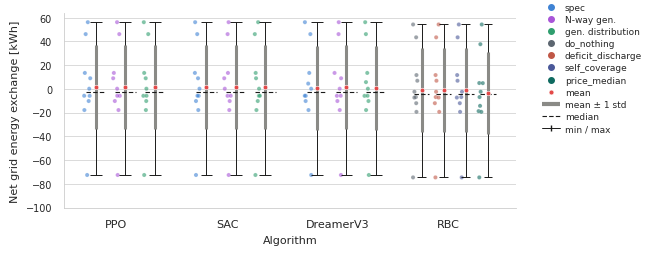

saved eval_4_20261001_102836_out_11.pdf  (cum_E_kWh, eval_4 = BES 11.0 kW, PV 6 kW, 6.30 x 2.40 in)


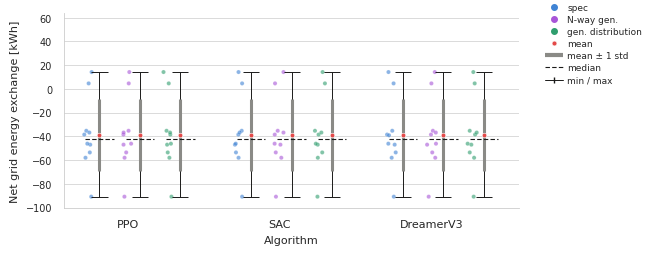

saved eval_5_20261001_102836_out_12.pdf  (cum_E_kWh, eval_5 = BES 11.0 kW, PV 12 kW, 6.30 x 2.40 in)


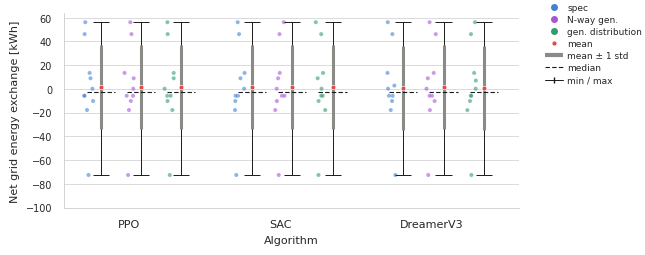

saved eval_0_20261001_102836_out_13.pdf  (cum_price_EUR, eval_0 = BES 3.7 kW, PV 6 kW, 6.30 x 2.40 in)


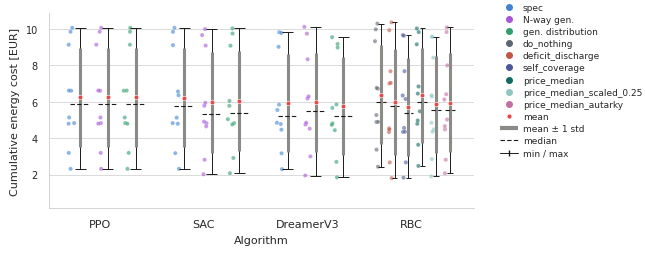

saved eval_1_20261001_102836_out_14.pdf  (cum_price_EUR, eval_1 = BES 3.7 kW, PV 12 kW, 6.30 x 2.40 in)


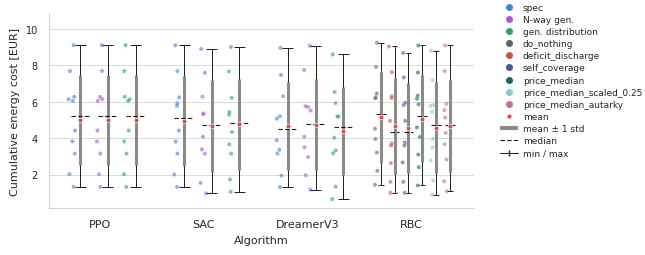

saved eval_2_20261001_102836_out_15.pdf  (cum_price_EUR, eval_2 = BES 8.0 kW, PV 6 kW, 6.30 x 2.40 in)


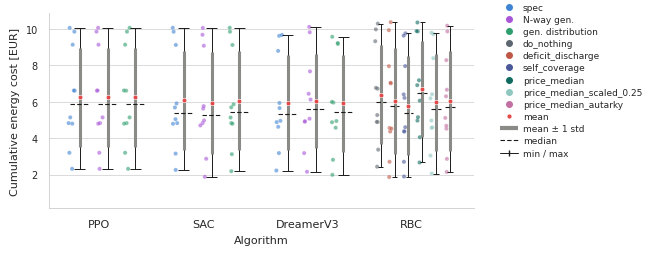

saved eval_3_20261001_102836_out_16.pdf  (cum_price_EUR, eval_3 = BES 8.0 kW, PV 12 kW, 6.30 x 2.40 in)


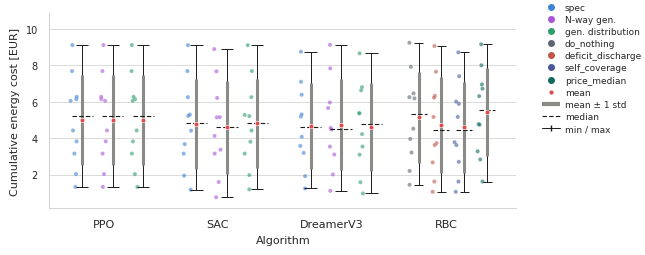

saved eval_4_20261001_102836_out_17.pdf  (cum_price_EUR, eval_4 = BES 11.0 kW, PV 6 kW, 6.30 x 2.40 in)


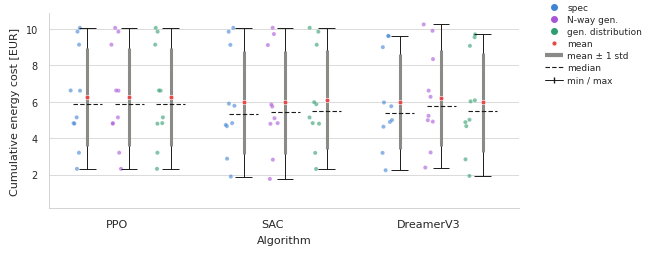

saved eval_5_20261001_102836_out_18.pdf  (cum_price_EUR, eval_5 = BES 11.0 kW, PV 12 kW, 6.30 x 2.40 in)


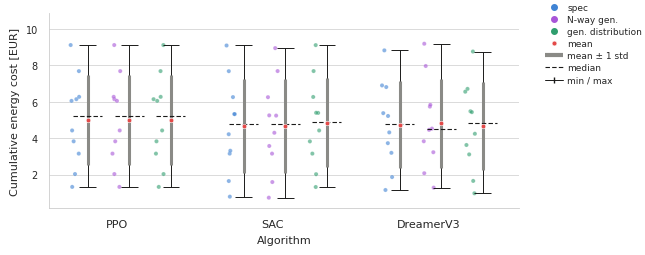

In [6]:
# One run = every (metric, eval setting) figure. The eval settings of one metric come
# out consecutively in `setting_labels` order, sharing a y-axis when
# SHARE_Y_ACROSS_EVAL_CFGS is set — so a metric's PDFs are exactly the set meant to be
# stacked on one A4 page.
for metric in present_metrics:
    shared_ylim = _shared_ylim(metric) if SHARE_Y_ACROSS_EVAL_CFGS else None
    for eval_cfg in setting_labels:
        catplot_for_metric(metric, eval_cfg, ylim=shared_ylim)


## Per-strip statistics

One row per (eval setting, algorithm, variant) — the exact values behind the stat glyphs, over
that strip's pooled episodes: `count`, `mean` (red dot), `std` (grey-bar half-length), `median`
(dashed line), `min` and `max` per metric. Rows follow the figure order: settings as drawn, then
the x-axis algorithms and their dodged variants.

To export these numbers (CSV + LaTeX body, settings side by side as columns) run
`sps_eval_stats_table_algo_cmp.ipynb` — it reuses this notebook's main-input, discovery and load
cells, so it picks up exactly the same data.

In [7]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
strip_stats = episodes.groupby(["eval_cfg", "algo", "variant"])[present_metrics].agg(
    ["count", "mean", "std", "median", "min", "max"]
).reindex(setting_labels, level="eval_cfg").reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")
strip_stats


total_reward                        \
                                            count       mean        std   
eval_cfg algo      variant                                                
eval_0   PPO       spec                        10 -31.345105  15.247068   
                   N-way gen.                  10 -31.345105  15.247068   
                   gen. distribution           10 -31.345105  15.247068   
         SAC       spec                        10 -31.142226  15.140719   
                   N-way gen.                  10 -29.745437  14.927548   
...                                           ...        ...        ...   
eval_5   SAC       N-way gen.                  10 -23.937446  15.485322   
                   gen. distribution           10 -24.928007  15.169020   
         DreamerV3 spec                        10 -24.177726  14.664511   
                   N-way gen.                  10 -25.324158  15.990880   
                   gen. distribution           10 -23.881986  15.003159   

                                                                       \
                                         median        min        max   
eval_cfg algo      variant                                              
eval_0   PPO       spec              -30.561745 -62.989806 -12.219591   
                   N-way gen.        -30.561745 -62.989806 -12.219591   
                   gen. distribution -30.561745 -62.989806 -12.219591   
         SAC       spec              -30.551934 -62.940750 -12.214757   
                   N-way gen.        -30.085970 -61.808946 -10.648156   
...                                         ...        ...        ...   
eval_5   SAC       N-way gen.        -23.716803 -57.231365  -3.859979   
                   gen. distribution -24.489837 -58.286791  -6.954330   
         DreamerV3 spec              -22.761853 -56.438099  -6.086487   
                   N-way gen.        -24.840371 -58.766713  -6.758909   
                   gen. distribution -22.307749 -56.029882  -5.132861   

                                     cum_E_kWh                        \
                                         count       mean        std   
eval_cfg algo      variant                                             
eval_0   PPO       spec                     10 -38.721610  30.038681   
                   N-way gen.               10 -38.721610  30.038681   
                   gen. distribution        10 -38.721610  30.038681   
         SAC       spec                     10 -38.721610  30.038681   
                   N-way gen.               10 -38.733258  30.037869   
...                                        ...        ...        ...   
eval_5   SAC       N-way gen.               10   1.269247  35.412318   
                   gen. distribution        10   1.269247  35.412318   
         DreamerV3 spec                     10   0.652179  35.316981   
                   N-way gen.               10   1.269247  35.412318   
                   gen. distribution        10   1.066881  35.374961   

                                                                       \
                                         median        min        max   
eval_cfg algo      variant                                              
eval_0   PPO       spec              -42.326820 -90.794424  14.196651   
                   N-way gen.        -42.326820 -90.794424  14.196651   
                   gen. distribution -42.326820 -90.794424  14.196651   
         SAC       spec              -42.326820 -90.794424  14.196651   
                   N-way gen.        -42.326820 -90.794424  14.196651   
...                                         ...        ...        ...   
eval_5   SAC       N-way gen.         -2.825085 -72.538173  56.203090   
                   gen. distribution  -2.825085 -72.538173  56.203090   
         DreamerV3 spec               -2.825085 -72.538173  56.203090   
                   N-way gen.         -2.825085 -72.538173  56.203090   
     

## Variance across eval seeds, per (eval setting, algorithm, variant)

Per strip, the metric mean is first taken within each eval seed, then aggregated (`mean` / `std`
/ `min` / `max`) across seeds — a small `std` means the result is consistent across eval seeds
rather than a lucky episode draw. With one seed per source the `std` is `NaN` and
`min` = `mean` = `max`; it only becomes informative once `_seed<N>` fan-outs exist and `SEEDS`
keeps more than one (it is pinned to `[42]` above).

In [8]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
seed_means = episodes.groupby(["eval_cfg", "algo", "variant", "seed"])[present_metrics].mean()
seed_means.groupby(["eval_cfg", "algo", "variant"]).agg(
    ["mean", "std", "min", "max"]
).reindex(setting_labels, level="eval_cfg").reindex(algo_labels, level="algo").reindex(variant_labels, level="variant")


total_reward                            \
                                             mean std        min        max   
eval_cfg algo      variant                                                    
eval_0   PPO       spec                -31.345105 NaN -31.345105 -31.345105   
                   N-way gen.          -31.345105 NaN -31.345105 -31.345105   
                   gen. distribution   -31.345105 NaN -31.345105 -31.345105   
         SAC       spec                -31.142226 NaN -31.142226 -31.142226   
                   N-way gen.          -29.745437 NaN -29.745437 -29.745437   
...                                           ...  ..        ...        ...   
eval_5   SAC       N-way gen.          -23.937446 NaN -23.937446 -23.937446   
                   gen. distribution   -24.928007 NaN -24.928007 -24.928007   
         DreamerV3 spec                -24.177726 NaN -24.177726 -24.177726   
                   N-way gen.          -25.324158 NaN -25.324158 -25.324158   
                   gen. distribution   -23.881986 NaN -23.881986 -23.881986   

                                      cum_E_kWh                            \
                                           mean std        min        max   
eval_cfg algo      variant                                                  
eval_0   PPO       spec              -38.721610 NaN -38.721610 -38.721610   
                   N-way gen.        -38.721610 NaN -38.721610 -38.721610   
                   gen. distribution -38.721610 NaN -38.721610 -38.721610   
         SAC       spec              -38.721610 NaN -38.721610 -38.721610   
                   N-way gen.        -38.733258 NaN -38.733258 -38.733258   
...                                         ...  ..        ...        ...   
eval_5   SAC       N-way gen.          1.269247 NaN   1.269247   1.269247   
                   gen. distribution   1.269247 NaN   1.269247   1.269247   
         DreamerV3 spec                0.652179 NaN   0.652179   0.652179   
                   N-way gen.          1.269247 NaN   1.269247   1.269247   
                   gen. distribution   1.066881 NaN   1.066881   1.066881   

                                     cum_price_EUR                          
                                              mean std       min       max  
eval_cfg algo      variant                                                  
eval_0   PPO       spec                   6.251721 NaN  6.251721  6.251721  
                   N-way gen.             6.251721 NaN  6.251721  6.251721  
                   gen. distribution      6.251721 NaN  6.251721  6.251721  
         SAC       spec                   6.216191 NaN  6.216191  6.216191  
                   N-way gen.             5.966488 NaN  5.966488  5.966488  
...                                            ...  ..       ...       ...  
eval_5   SAC       N-way gen.             4.670621 NaN  4.670621  4.670621  
                   gen. distribution      4.857013 NaN  4.857013  4.857013  
         DreamerV3 spec                   4.736681 NaN  4.736681  4.736681  
                   N-way gen.             4.810296 NaN  4.810296  4.810296  
                   gen. distribution      4.651618 NaN  4.651618  4.651618  

[76 rows x 12 columns]